# 1. Contexto

Este proyecto se desarrolla en el marco del **Proyecto Integrador de Machine Learning** y tiene como propósito aplicar técnicas de **clasificación supervisada** para predecir el riesgo de incumplimiento en préstamos otorgados por la plataforma **Lending Club**.

El dataset proviene de **Kaggle (Lending Club Loan Data 2007–2020)** y contiene información de más de **1,3 millones de registros** de préstamos, tanto aceptados como rechazados. Cada registro incluye variables relacionadas con las características del solicitante (socioeconómicas, financieras, historial crediticio y empleo), así como con el propósito y condiciones del préstamo.

La variable objetivo (`default`) se genera a partir de la columna `loan_status`, codificada de la siguiente manera:

- `0`: Fully Paid (el préstamo fue pagado completamente)  
- `1`: Charged Off (el préstamo cayó en default/incumplimiento)  

```python



# 2. Importación de librerías

In [1]:
!pip install -q pyspark

In [2]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.feature import Imputer
import pyspark.sql.functions as F
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.types import *
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, countDistinct, isnan, when, avg, min, max, stddev


ModuleNotFoundError: No module named 'missingno'

# 3. Carga y exploración de datos usando PySpark (EDA)

In [23]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Exploratorio_PySpark") \
    .getOrCreate()

# Leer CSV con encabezados e inferencia de tipos
df = spark.read.csv("/kaggle/input/kikipyspark/accepted_2007_to_2018Q4.csv", 
                    header=True, 
                    inferSchema=True)
spark.sparkContext.setLogLevel("ERROR")
# Vista rápida
# Mostrar solo algunas columnas y pocas filas
df.select("loan_amnt", "int_rate", "term", "grade", "loan_status").show(20, truncate=False)

+---------+--------+----------+-----+-----------+
|loan_amnt|int_rate|term      |grade|loan_status|
+---------+--------+----------+-----+-----------+
|3600.0   |13.99   | 36 months|C    |Fully Paid |
|24700.0  |11.99   | 36 months|C    |Fully Paid |
|20000.0  |10.78   | 60 months|B    |Fully Paid |
|35000.0  |14.85   | 60 months|C    |Current    |
|10400.0  |22.45   | 60 months|F    |Fully Paid |
|11950.0  |13.44   | 36 months|C    |Fully Paid |
|20000.0  |9.17    | 36 months|B    |Fully Paid |
|20000.0  |8.49    | 36 months|B    |Fully Paid |
|10000.0  |6.49    | 36 months|A    |Fully Paid |
|8000.0   |11.48   | 36 months|B    |Fully Paid |
|22400.0  |12.88   | 60 months|C    |Current    |
|16000.0  |12.88   | 60 months|C    |Current    |
|1400.0   |12.88   | 36 months|C    |Fully Paid |
|18000.0  |19.48   | 60 months|E    |Charged Off|
|28000.0  |6.49    | 36 months|A    |Fully Paid |
|9600.0   |7.49    | 36 months|A    |Fully Paid |
|25000.0  |7.49    | 36 months|A    |Fully Paid |


## 3.2 Información básica con PySpark

In [24]:
print("=== Dimensiones del DataFrame ===")
print(f"Filas: {df.count()}  |  Columnas: {len(df.columns)}")

# 1) Schema
print("\n=== Esquema del DataFrame ===")
df.printSchema()

# 2) Conteo de nulos por columna
print("\n=== Valores nulos por columna ===")
nulos = df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c) for c in df.columns
])
nulos.show(vertical=True)

=== Dimensiones del DataFrame ===


Filas: 2260701  |  Columnas: 151

=== Esquema del DataFrame ===
root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- funded_amnt: double (nullable = true)
 |-- funded_amnt_inv: double (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: string (nullable = t

-RECORD 0---------------------------------------------
 id                                         | 0       
 member_id                                  | 2260701 
 loan_amnt                                  | 33      
 funded_amnt                                | 33      
 funded_amnt_inv                            | 33      
 term                                       | 33      
 int_rate                                   | 33      
 installment                                | 33      
 grade                                      | 33      
 sub_grade                                  | 33      
 emp_title                                  | 167002  
 emp_length                                 | 146940  
 home_ownership                             | 33      
 annual_inc                                 | 37      
 verification_status                        | 33      
 issue_d                                    | 33      
 loan_status                                | 33      
 pymnt_pla

### Resumen del DataFrame  
- **Valores nulos:** Varias variables presentan muchos valores faltantes  
  *(ejemplo: `desc`, `annual_inc_joint`, `sec_app_`, `hardship_`)* → no todas son útiles para un análisis general.


###  Información de los préstamos
- **Monto promedio:** ~15K USD (máx. 40K).  
- **Tasa de interés media:** 13%.  
- **Plazos:** Mayoría a **36 o 60 meses**.  

### Información de los prestatarios
- **Ingreso anual promedio:** ~78K USD (con alta dispersión).  
- **Rango FICO típico:** ~690–700 → refleja **riesgo crediticio medio**.


In [25]:
# 4) Distribución de loan_status)
print("\n=== Distribución de loan_status ===")
if "loan_status" in df.columns:
    df.groupBy("loan_status").count().orderBy("count", ascending=False).show()


=== Distribución de loan_status ===


+--------------------+-------+
|         loan_status|  count|
+--------------------+-------+
|          Fully Paid|1076751|
|             Current| 878317|
|         Charged Off| 268558|
|  Late (31-120 days)|  21467|
|     In Grace Period|   8436|
|   Late (16-30 days)|   4349|
|Does not meet the...|   1988|
|Does not meet the...|    761|
|             Default|     40|
|                NULL|     33|
|            Oct-2015|      1|
+--------------------+-------+



### Variable `loan_status`

La variable `loan_status` indica el estado final o actual de cada préstamo en Lending Club.  
Su distribución es la siguiente:

- **Préstamos pagados en su totalidad (Fully Paid):** 1.07M → son la **mayoría** de los casos.  
- **Préstamos actuales (Current):** 878K → muchos aún están en curso.  
- **Incumplimientos / pérdidas:**  
  - *Charged Off:* 268K (~10%) → representan los **casos incobrables**.  
  - *Default + Late (varios rangos):* suman decenas de miles → muestran un **riesgo latente**.  
- **Valores atípicos:** etiquetas como `Oct-2015` o `NULL` parecen **errores de registro**.  

### Interpretación de categorías

- **Fully Paid** → El préstamo fue pagado en su totalidad. Se clasifica como **0 (no default)**.  
- **Charged Off** → El préstamo fue castigado como pérdida. Se clasifica como **1 (default)**.  
- **Default** → Incumplimiento total, equivalente a *Charged Off*, pero solo hay 40. → **Se excluye**
- **Current** → El préstamo sigue en curso. → **Se excluye** del dataset.  
- **In Grace Period** → El cliente aún está en período de gracia. → **Se excluye**.  
- **Late (16–30 days)** → Atraso de 16–30 días. → **Se excluye**.  
- **Late (31–120 days)** → Atraso de 31–120 días. → **Se excluye**.  
- **Does not meet the credit policy: Status = Fully Paid** → No cumplía políticas, pero fue pagado.   → **Se excluye**.
- **Does not meet the credit policy: Status = Charged Off** → No cumplía políticas y terminó en default.  → **Se excluye**.

Nos quedaremos con Fully Paid y con Charged Off

In [26]:
# 5) Top categorías más frecuentes en 'grade'
print("\n=== Distribución de grade ===")
if "grade" in df.columns:
    df.groupBy("grade").count().orderBy("grade").show()

# 6) Correlación rápida (ejemplo entre loan_amnt y int_rate si existen)
print("\n=== Correlación ===")
if "loan_amnt" in df.columns and "int_rate" in df.columns:
    print("Correlación loan_amnt - int_rate:", df.stat.corr("loan_amnt", "int_rate"))


=== Distribución de grade ===


+-----+------+
|grade| count|
+-----+------+
| NULL|    33|
|    A|433027|
|    B|663557|
|    C|650053|
|    D|324424|
|    E|135639|
|    F| 41800|
|    G| 12168|
+-----+------+


=== Correlación ===


Correlación loan_amnt - int_rate: 0.09813935834177831


### Distribución de *grade*
- **Grades más frecuentes:**  
  - `B` (663K) y `C` (650K) → concentran la mayoría de los préstamos.  
  - `A` (433K) → también alta participación.  
- **Grades bajos (`E`, `F`, `G`):** menos comunes, pero representan **mayor riesgo crediticio**.  
- **Nulos:** 33 casos → insignificantes, pero a limpiar.

### Correlación *loan_amnt* – *int_rate*
- **Coeficiente:** 0.098 → **muy baja correlación positiva**.  
- Implica que el **monto del préstamo casi no influye** en la tasa de interés;  
  lo determinante son otras variables que veremos a futuro.


## 3.3 Tratamiento de datos faltante

Para este paso, nos enfocaremos únicamente en las variables que presentan **más del 40% de datos faltantes**.  
Esto nos permitirá identificar aquellas columnas que podrían:

- Ser **irrelevantes** para el modelo.  
- Requerir un **tratamiento especial** (imputación, eliminación o transformación).  
- Indicar posibles **problemas de calidad de datos** en el dataset.  


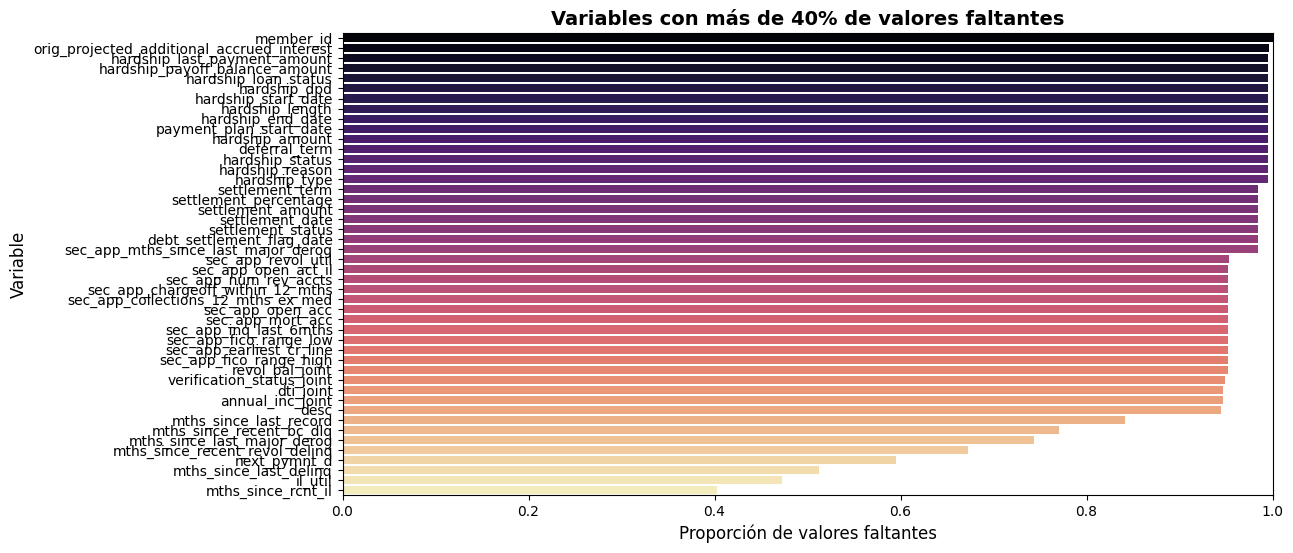

In [27]:
# Calculamos proporción de missing por columna
missing_df = df.select([
    (1 - (F.count(c) / F.count('*'))).alias(c)
    for c in df.columns
]).toPandas()

# Transponemos para dejar "variable - missing_rate"
missing_df = missing_df.T.reset_index()
missing_df.columns = ["variable", "missing_rate"]

# Filtramos solo las que tienen más de 40% de valores faltantes
missing_df = missing_df[missing_df["missing_rate"] > 0.40]\
                       .sort_values("missing_rate", ascending=False)

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    data=missing_df, 
    x="missing_rate", 
    y="variable", 
    palette="magma"
)
plt.title("Variables con más de 40% de valores faltantes", fontsize=14, weight="bold")
plt.xlabel("Proporción de valores faltantes", fontsize=12)
plt.ylabel("Variable", fontsize=12)
plt.xlim(0, 1)
plt.show()


Procedemos a eliminar las columnas, ya que aportan poco valor y su imputación introduciría demasiado ruido.    

In [28]:
# Lista de columnas con más de 40% missing
cols_to_drop = missing_df["variable"].tolist()

print(f"Eliminaremos {len(cols_to_drop)} columnas con >40% de valores faltantes")

# Eliminamos del DataFrame en PySpark
df_clean = df.drop(*cols_to_drop)

# Verificamos nuevo número de columnas
print(f"Antes: {len(df.columns)} columnas")
print(f"Después: {len(df_clean.columns)} columnas")

Eliminaremos 46 columnas con >40% de valores faltantes
Antes: 151 columnas
Después: 105 columnas


## 3.4 Visualizaciones con PySpark
### Tratamiento de la variable Loan Status

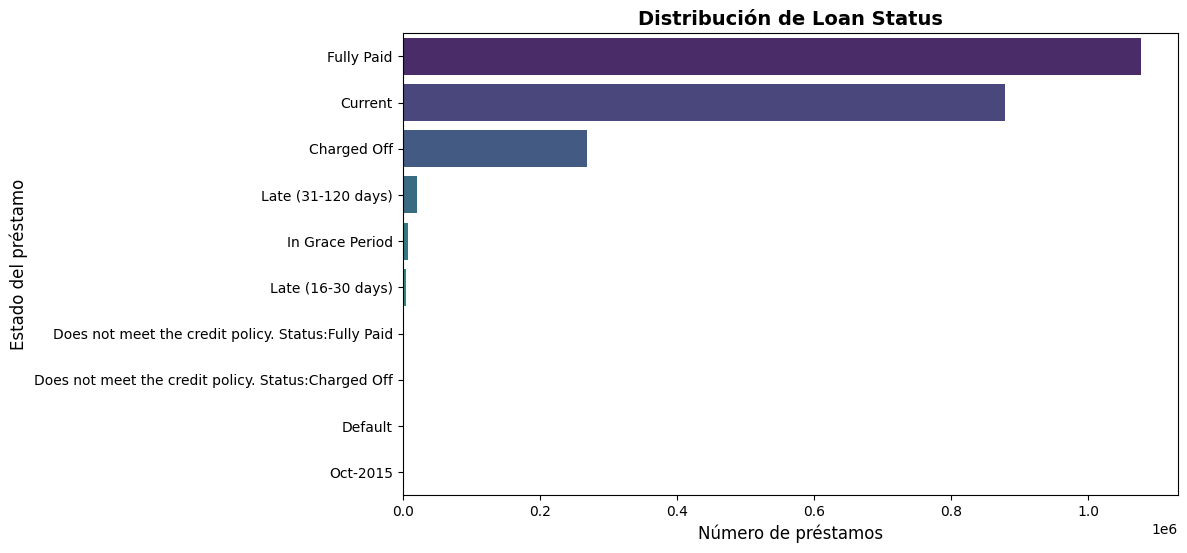

In [45]:
# 1. Distribución Loan Status
loan_status_counts = (
    df_clean.groupBy("loan_status")
            .count()
            .orderBy("count", ascending=False)
            .toPandas()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=loan_status_counts,
    x="count",
    y="loan_status",
    palette="viridis"
)
plt.title("Distribución de Loan Status", fontsize=14, weight="bold")
plt.xlabel("Número de préstamos", fontsize=12)
plt.ylabel("Estado del préstamo", fontsize=12)
plt.show()


Como comentamos antes nos enfocaremos en los préstamos con estado **'Fully Paid'** y **'Charged Off'** y creamos nustra la variable binaria target **loan_default**

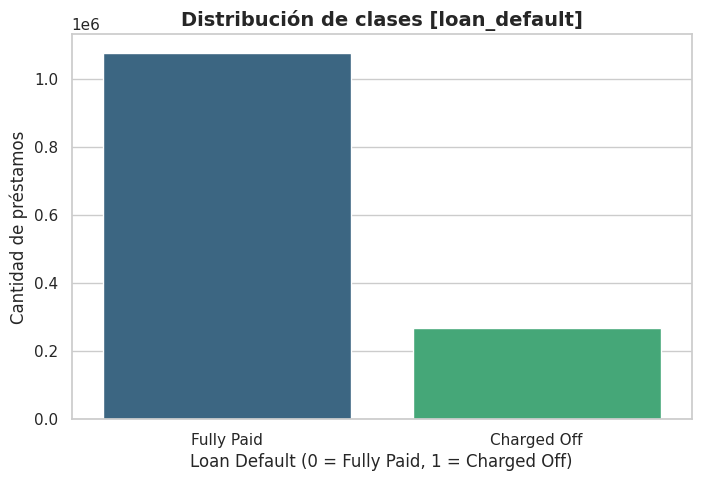

In [61]:
df_bin_pd = df_bin.groupBy("loan_default").count().toPandas()

df_bin_pd = df_bin_pd.sort_values("loan_default")

sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

# Barplot
sns.barplot(
    x="loan_default",
    y="count",
    data=df_bin_pd,
    palette="viridis"
)

plt.xlabel("Loan Default (0 = Fully Paid, 1 = Charged Off)", fontsize=12)
plt.ylabel("Cantidad de préstamos", fontsize=12)
plt.title("Distribución de Clases [loan_default]", fontsize=14, weight="bold")
plt.xticks([0,1], ["Fully Paid", "Charged Off"])
plt.show()


> **Nota:** La variable `loan_default` presenta un **fuerte desbalanceo de clases**.  
> Solo ~20% de los préstamos terminan en *default* (268K) frente a ~80% que son *fully paid* (1.07M).  
> Este desbalance puede afectar los modelos de clasificación, favoreciendo la predicción de la clase mayoritaria.  
> Será necesario considerar técnicas como **oversampling o de undersampling**.


### Análisis de Montos de Préstamos

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


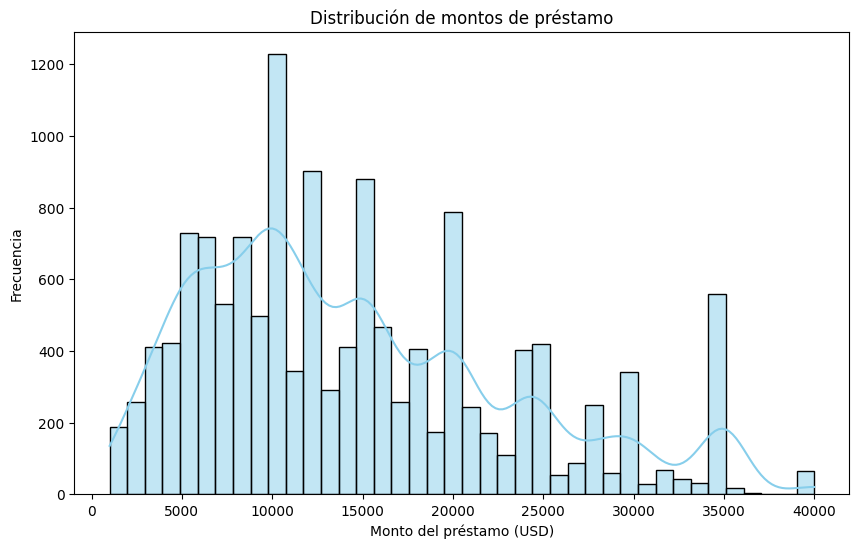

In [49]:
# 2. Distribución Loan Amount
loan_amount_sample = df_bin.select("loan_amnt").sample(False, 0.01, seed=42).toPandas()

plt.figure(figsize=(10,6))
sns.histplot(loan_amount_sample["loan_amnt"], bins=40, kde=True, color="skyblue")
plt.title("Distribución de montos de préstamo")
plt.xlabel("Monto del préstamo (USD)")
plt.ylabel("Frecuencia")
plt.show()

- **Rango de préstamos:** aproximadamente entre 1.000 a 40.000 USD, con concentración entre 5.000 y 20.000 USD.
- **Montos más frecuentes:** picos alrededor de 10,000, y 15,000 USD, indicando preferencia por montos “redondeados” o estándar.
- **Distribución:** asimétrica hacia la derecha (right-skewed), con muchos préstamos bajos y medianos, y pocos préstamos grandes cercanos a $40,000.
- La mayoría de los préstamos son moderados, lo que podría implicar menor riesgo. Los préstamos grandes podrían tener mayor probabilidad de default.


### Tasa de Interés vs. Default del Préstamo

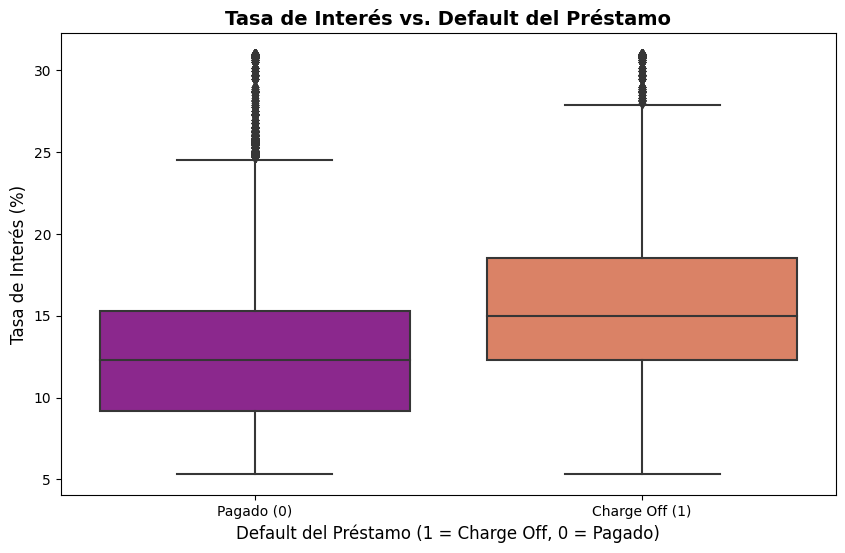

In [56]:
# Extraemos la columna 'int_rate' y la convertimos a un tipo numérico (si es string)
from pyspark.sql.functions import regexp_replace, col

# Nota: Asumiendo que 'int_rate' es un string como '12.99 %', lo limpiamos primero
df_bin_numeric = df_bin.withColumn("int_rate_num", regexp_replace(col("int_rate"), "%", "").cast("float"))

# Ahora hacemos el análisis
sample_int_rate = df_bin_numeric.select("int_rate_num", "loan_default").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(data=sample_int_rate, x="loan_default", y="int_rate_num", palette="plasma")
plt.title("Tasa de Interés vs. Default del Préstamo", fontsize=14, weight="bold")
plt.xlabel("Default del Préstamo (1 = Charge Off, 0 = Pagado)", fontsize=12)
plt.ylabel("Tasa de Interés (%)", fontsize=12)
plt.xticks([0, 1], ['Pagado (0)', 'Charge Off (1)'])
plt.show()

Los préstamos con tasas de interés más altas muestran una probabilidad significativamente mayor de caer en **default**, confirmando su papel como un fuerte indicador de riesgo crediticio.


### Tasa de Interés Promedio por Grado

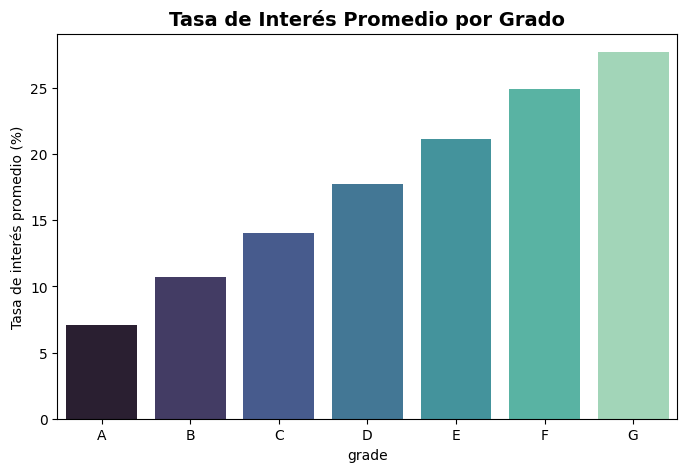

In [32]:
grade_rate = (
    df_bin.groupBy("grade")
          .agg(F.avg("int_rate").alias("avg_int_rate"))
          .orderBy("grade")
          .toPandas()
)

plt.figure(figsize=(8,5))
sns.barplot(data=grade_rate, x="grade", y="avg_int_rate", palette="mako")
plt.title("Tasa de Interés Promedio por Grado", fontsize=14, weight="bold")
plt.ylabel("Tasa de interés promedio (%)")
plt.show()

Tasas más altas en grados bajos (peor calidad crediticia).

### home_ownership vs default rate 

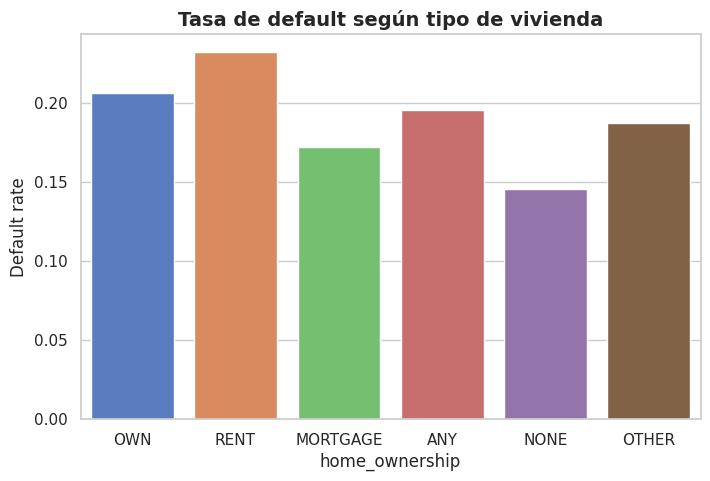

In [66]:
home = (
    df_bin.groupBy("home_ownership")
          .agg(F.mean("loan_default").alias("default_rate"))
          .toPandas()
)

plt.figure(figsize=(8,5))
sns.barplot(data=home, x="home_ownership", y="default_rate", palette="muted")
plt.title("Tasa de default según tipo de vivienda", fontsize=14, weight="bold")
plt.ylabel("Default rate")
plt.show()


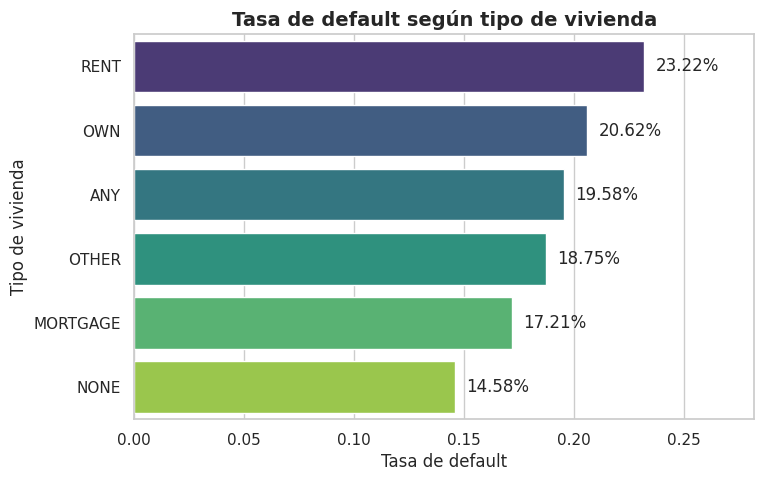

In [68]:
# Agrupar por tipo de vivienda y calcular tasa de default
home = (
    df_bin.groupBy("home_ownership")
          .agg(F.mean("loan_default").alias("default_rate"))
          .toPandas()
)

# Ordenar por default_rate de mayor a menor para mejor interpretación
home = home.sort_values("default_rate", ascending=False)

# Configuración de estilo
sns.set_style("whitegrid")
plt.figure(figsize=(8,5))

# Barplot
sns.barplot(
    data=home,
    x="default_rate",
    y="home_ownership",
    palette="viridis"
)

# Añadir etiquetas y título
plt.xlabel("Tasa de default", fontsize=12)
plt.ylabel("Tipo de vivienda", fontsize=12)
plt.title("Tasa de default según tipo de vivienda", fontsize=14, weight="bold")

# Añadir etiquetas de porcentaje encima de cada barra
for index, value in enumerate(home["default_rate"]):
    plt.text(value + 0.005, index, f"{value:.2%}", va='center')

plt.xlim(0, home["default_rate"].max() + 0.05)  # Ajustar límite x
plt.show()


El análisis revela una fuerte correlación entre el tipo de vivienda y el riesgo de incumplimiento, actuando como un claro indicador de la estabilidad financiera del prestatario. Los inquilinos (RENT) presentan el riesgo más alto con un 23.2%, seguidos por los propietarios sin deuda (OWN) con un 20.6%, mientras que aquellos que pagan una hipoteca (MORTGAGE) representan el grupo más fiable con la tasa más baja, un 17.2%. Esto confirma que los prestatarios con un mayor compromiso financiero en su vivienda tienden a ser un riesgo crediticio menor.

### Mapa de calor de correlaciones entre variables financieras

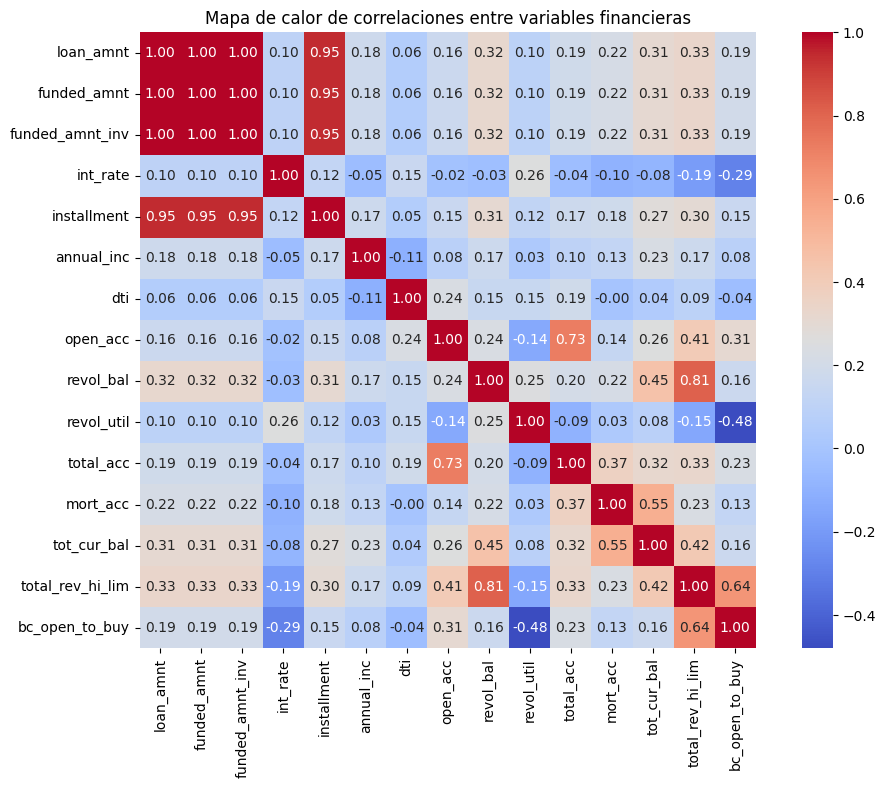

In [34]:
# Selección de variables numéricas de interés
num_cols = [
    "loan_amnt", "funded_amnt", "funded_amnt_inv",
    "int_rate", "installment", "annual_inc",
    "dti", "open_acc", "revol_bal", "revol_util",
    "total_acc", "mort_acc", "tot_cur_bal",
    "total_rev_hi_lim", "bc_open_to_buy"
]

# Pasamos un sample a Pandas para manejarlo
numeric_sample = df.select(num_cols).dropna().sample(False, 0.01, seed=42).toPandas()

# Calcular matriz de correlaciones
corr = numeric_sample.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Mapa de calor de correlaciones entre variables financieras")
plt.show()



Al finalizar el  Análisis Exploratorio de Datos nos qudamos con algunos **Hallazgos Principales:**

*   **Desbalance de Clases:** Al filtrar los datos para quedarnos únicamente con préstamos finalizados ('Fully Paid' y 'Charged Off'), se ha confirmado un fuerte desbalance: aproximadamente el **80%** de los préstamos son pagados, mientras que solo el **20%** resulta en default. Esto será un factor crucial a manejar durante el modelado.
   
*   **Indicadores de Riesgo Financiero:** Se observa una clara correlación positiva entre el riesgo de default y las variables financieras. Préstamos con **montos (`loan_amnt`) más altos** y, de forma más pronunciada, con **tasas de interés (`int_rate`) elevadas**, tienen una mayor propensión al incumplimiento.

*   **Estabilidad del Prestatario:** Variables como el tipo de vivienda (`home_ownership`) y el grado del préstamo (`grade`) actúan como un buen proxy de la estabilidad financiera. Los **inquilinos (`RENT`)** muestran la tasa de default más alta, mientras que los **propietarios con hipoteca (`MORTGAGE`)** son el grupo de menor riesgo.

Este análisis ha validado la relevancia de las variables seleccionadas y ha sentado las bases para la siguiente etapa. Con una comprensión clara de los datos, procederemos ahora a la fase de **Modelado Predictivo**, donde construiremos y evaluaremos los modelos de clasificación con PySpark y scikit-learn para predecir la probabilidad de default.